In [1]:
from IPython.display import SVG, display

from logogen import generate_logo_svg, Roundedness

In [26]:
from dataclasses import dataclass

@dataclass
class Roundedness:
    top_left: float
    top_right: float
    mid_right_up: float
    mid_right_down: float

def generate_logo_svg(
    width: float = 200,
    height: float = 200,
    line_thickness: float = 30,
    crossbar_pos: float = 0.5,   # 0 = top, 1 = bottom (relative)
    roundedness: float | Roundedness = 20.0,   # radius of the curved right angles
    base_color: str = "#000000",
    cap_color: str = "#000000",
) -> str:
    """
    Generate an SVG for an H-like logo where:
      - left vertical is straight
      - top bar is straight
      - right vertical is split into upper + lower with a middle bar
      - top-left, top-right, and both middle-right stroke corners are
        explicit quarter-circle arcs ("protractor turns")
      - middle-left corner is sharp

    width, height: total SVG size
    line_thickness: stroke width of all segments
    crossbar_pos: vertical position of middle bar as a fraction of height (0..1 from top)
    roundedness: geometric radius r of the curved corners (in SVG units)
    """
    if isinstance(roundedness, (float, int)):
        roundedness = Roundedness(
            top_left=roundedness,
            top_right=roundedness,
            mid_right_up=roundedness,
            mid_right_down=roundedness,
        )
    # TODO: use per-corner values instead of fixed float below!

    # basic sanity
    w = max(10.0, float(width))
    h = max(10.0, float(height))
    t = max(1.0, float(line_thickness))

    # centerlines: keep strokes inside the SVG by half a thickness
    x_left = t / 2.0
    x_right = w - t / 2.0
    y_top = t / 2.0
    y_bottom = h - t / 2.0

    # raw crossbar center, clamp to a reasonable vertical band
    y_mid_raw = float(crossbar_pos) * h
    y_mid = max(y_top + 2 * t, min(y_bottom - 2 * t, y_mid_raw))

    # choose per-corner radii that actually fit:
    # - can't exceed half the vertical gap from top to middle
    # - can't exceed half the vertical gap from middle to bottom
    # - can't exceed a fraction of the horizontal span
    max_r_vert_top = max(1.0, (y_mid - y_top) / 2.0)
    max_r_vert_bottom = max(1.0, (y_bottom - y_mid) / 2.0)
    max_r_horiz = max(1.0, (x_right - x_left) / 4.0)

    def _clamp_corner(val: float, max_vert: float, max_horiz: float) -> float:
        return max(1.0, min(float(val), max_vert, max_horiz))

    r_tl = _clamp_corner(roundedness.top_left,     max_r_vert_top,    max_r_horiz)
    r_tr = _clamp_corner(roundedness.top_right,    max_r_vert_top,    max_r_horiz)
    r_mru = _clamp_corner(roundedness.mid_right_up,   max_r_vert_top,    max_r_horiz)
    r_mrd = _clamp_corner(roundedness.mid_right_down, max_r_vert_bottom, max_r_horiz)

    # === key points (centerline coordinates) ===

    # left side
    BL = (x_left, y_bottom)  # bottom-left leg end
    TL_arc_start = (x_left, y_top + r_tl)        # where top-left arc starts on vertical
    TL_arc_end   = (x_left + r_tl, y_top)        # where top-left arc ends on horizontal

    # top bar
    TR_arc_start = (x_right - r_tr, y_top)       # where top-right arc starts on horizontal
    TR_arc_end   = (x_right, y_top + r_tr)       # where top-right arc ends on vertical

    # right vertical near middle (note separate radii for up/down)
    MR_up   = (x_right, y_mid - r_mru)           # just above the middle-right corner on vertical
    MR_down = (x_right, y_mid + r_mrd)           # just below the middle-right corner on vertical
    MR_join_up   = (x_right - r_mru, y_mid)      # where upper middle arc meets the bar
    MR_join_down = (x_right - r_mrd, y_mid)      # where lower middle arc meets the bar

    # middle-left
    ML = (x_left, y_mid)


    # === straight segments: 5 lines ===

    lines = []

    # left vertical: bottom → just below top-left arc
    lines.append(
        f'<line x1="{BL[0]}" y1="{BL[1]}" x2="{TL_arc_start[0]}" y2="{TL_arc_start[1]}" />'
    )

    # top bar: between top-left arc end and top-right arc start
    lines.append(
        f'<line x1="{TL_arc_end[0]}" y1="{TL_arc_end[1]}" '
        f'x2="{TR_arc_start[0]}" y2="{TR_arc_start[1]}" '
        f'stroke="{cap_color}" />'
    )

    # right vertical upper: from just below top-right arc down to just above middle-right arcs
    lines.append(
        f'<line x1="{TR_arc_end[0]}" y1="{TR_arc_end[1]}" '
        f'x2="{MR_up[0]}" y2="{MR_up[1]}" />'
    )

    # right vertical lower: from just below the lower middle-right arc down to bottom-right
    lines.append(
        f'<line x1="{MR_down[0]}" y1="{MR_down[1]}" '
        f'x2="{x_right}" y2="{y_bottom}" />'
    )

    # middle bar: from left vertical to the rightmost of the two join points
    x_midbar_end = max(MR_join_up[0], MR_join_down[0])
    lines.append(
        f'<line x1="{ML[0]}" y1="{ML[1]}" '
        f'x2="{x_midbar_end}" y2="{ML[1]}" />'
    )

    # === arcs: 4 quarter circles (using SVG A commands) ===
    # They are separate paths, each stroked with the same width.

    arcs = []

    # top-left: from vertical up to horizontal right
    arcs.append(
        f'<path d="M {TL_arc_start[0]} {TL_arc_start[1]} '
        f'A {r_tl} {r_tl} 0 0 1 {TL_arc_end[0]} {TL_arc_end[1]}" '
        f'stroke="{cap_color}" />'
    )

    # top-right: from horizontal right to vertical down
    arcs.append(
        f'<path d="M {TR_arc_start[0]} {TR_arc_start[1]} '
        f'A {r_tr} {r_tr} 0 0 1 {TR_arc_end[0]} {TR_arc_end[1]}" '
        f'stroke="{cap_color}" />'
    )

    # middle-right (upward connection): mid bar → vertical above
    arcs.append(
        f'<path d="M {MR_join_up[0]} {MR_join_up[1]} '
        f'A {r_mru} {r_mru} 0 0 0 {MR_up[0]} {MR_up[1]}" />'
    )

    # middle-right (downward connection): mid bar → vertical below
    arcs.append(
        f'<path d="M {MR_join_down[0]} {MR_join_down[1]} '
        f'A {r_mrd} {r_mrd} 0 0 1 {MR_down[0]} {MR_down[1]}" />'
    )

    # === assemble SVG ===

    lines_svg = "\n    ".join(lines)
    arcs_svg = "\n    ".join(arcs)

    svg = f"""<svg xmlns="http://www.w3.org/2000/svg"
     width="{w}" height="{h}" viewBox="0 0 {w} {h}">
  <g fill="none"
     stroke="{base_color}"
     stroke-width="{t}"
     stroke-linecap="butt"
     stroke-linejoin="round">
    {lines_svg}
    {arcs_svg}
  </g>
</svg>
"""
    return svg

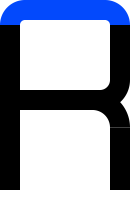

In [35]:
roundedness = Roundedness(
    top_left=15,
    top_right=15,
    mid_right_up=20,
    mid_right_down=100,
)

SVG(generate_logo_svg(
    width=130,
    height=200,
    line_thickness=20,
    crossbar_pos=0.5,
    roundedness=roundedness,
    cap_color="#0349fc",
))